<a href="https://colab.research.google.com/github/parthasarathipanda2006/Projects/blob/main/PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [93]:
def create_model():
  model={
      "Dense1":tf.keras.layers.Dense(20,activation='tanh'),
      "Dense2":tf.keras.layers.Dense(20,activation='tanh'),
      "Dense3":tf.keras.layers.Dense(20,activation='tanh'),
      "out_layer":tf.keras.layers.Dense(1),
  }
  return model

In [94]:
def call_model(model,x):
  for layer_name,layer in model.items():
    x=layer(x)
  return x

In [95]:
def DE(x,model):
  with tf.GradientTape(persistent=True) as tape:
    tape.watch(x)
    u = call_model(model, x) # Corrected line: pass 'model' as the first argument
    u_x = tape.gradient(u, x)
    u_xx = tape.gradient(u_x, x)
    del tape
    return u_xx+np.pi**2 * tf.sin(np.pi*x)

In [96]:
def loss(x,x_bc,y,model):
  loss=tf.reduce_mean(tf.square(DE(x,model)))
  y_bc=call_model(model,x_bc)
  loss_constant=tf.reduce_mean(tf.square(y-y_bc))
  return loss+loss_constant


In [97]:
def run_model(model,x,x_bc,y,optimizer):

  with tf.GradientTape() as tape:
    loss_val = loss(x,x_bc,y,model)

  variables = [var for layer in model.values() for var in layer.trainable_variables]
  grads = tape.gradient(loss_val, variables)

  optimizer.apply_gradients(zip(grads,variables))

  return loss_val

In [98]:
x_train=np.linspace(-1,1,500).reshape(-1,1) # Increased training points
x_train=tf.convert_to_tensor(x_train,dtype=tf.float32)

x_bc=np.array([[-1.0],[1.0]])
y_bc=np.array([[0.0],[0.0]])
x_bc=tf.convert_to_tensor(x_bc,dtype=tf.float32)
y_bc=tf.convert_to_tensor(y_bc,dtype=tf.float32)

model=create_model()
optimizer=tf.keras.optimizers.Adam(learning_rate=0.005)
epochs=2000 # Increased epochs
for epoch in range(epochs):
  loss_val=run_model(model,x_train,x_bc,y_bc,optimizer)
  if epoch % 1000 == 0:
    print(f"Epoch {epoch}, Loss {loss_val}")

Epoch 0, Loss 47.91754150390625
Epoch 1000, Loss 0.0006629095878452063


In [99]:
x_test=np.linspace(-1,1,500).reshape(-1,1)
x_test=tf.convert_to_tensor(x_test,dtype=tf.float32)
y_pred=call_model(model,x_test)
y_true=np.sin(np.pi*x_test)

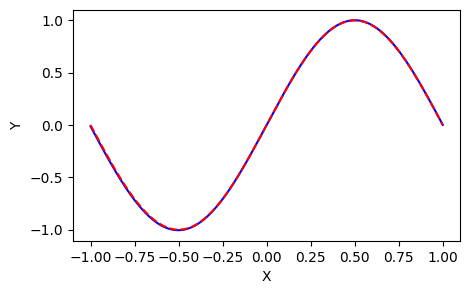

In [100]:
plt.figure(figsize=(5,3))
plt.plot(x_test,y_pred,'b-',label='predicted')
plt.plot(x_test,y_true,'r--',label='True')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()